In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor

In [2]:
train = pd.read_csv("Housetrain.csv")
test = pd.read_csv("Housetest.csv")

train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
test_ids = test["Id"]

In [4]:
train.drop("Id", axis=1, inplace=True)
test.drop("Id", axis=1, inplace=True)

y = train["SalePrice"]
train.drop("SalePrice", axis=1, inplace=True)

combined = pd.concat([train, test], axis=0)

In [6]:
# Fill numeric columns
num_cols = combined.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    combined[col] = combined[col].fillna(combined[col].median())

# Fill categorical columns
cat_cols = combined.select_dtypes(include=['object']).columns
for col in cat_cols:
    combined[col] = combined[col].fillna(combined[col].mode()[0])

In [8]:
le = LabelEncoder()

for col in cat_cols:
    combined[col] = le.fit_transform(combined[col])

In [9]:
X = combined[:len(train)]
X_test = combined[len(train):]

In [10]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X, y)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
predictions = model.predict(X_test)

In [14]:
submission = pd.DataFrame({
    "Id": test_ids,
    "SalePrice": predictions
})

submission.to_csv("Housesubmission.csv", index=False)

In [4]:
import pandas as pd

train = pd.read_csv("Housetrain.csv")

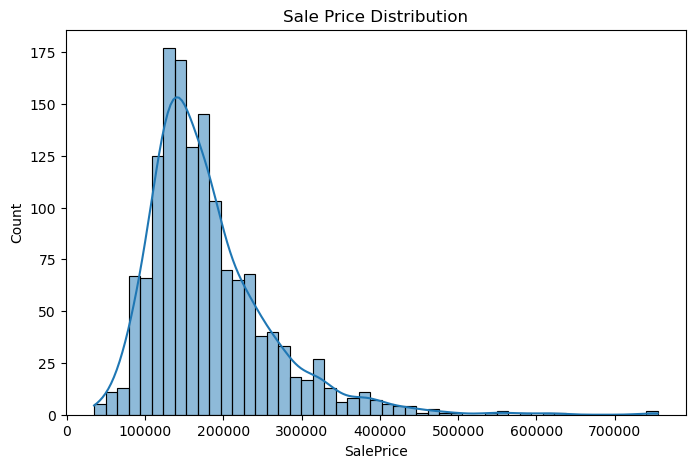

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], kde=True)
plt.title("Sale Price Distribution")
plt.show()